In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from google.colab import files
import io

In [ ]:
uploaded = files.upload()

# Assuming only one file is uploaded and it's a CSV
df = None
if uploaded:
    filename = list(uploaded.keys())[0]
    uploaded_file_content = uploaded[filename]
    print(f'User uploaded file "{filename}" with length {len(uploaded_file_content)} bytes')

    # Read the byte content into a pandas DataFrame, assuming CSV format
    try:
        df = pd.read_csv(io.BytesIO(uploaded_file_content))
        print(f'Successfully loaded "{filename}" into a pandas DataFrame.')
        display(df.head()) # Display the first 5 rows to confirm

        # --- Start of Processing and Download ---
        #dropping features based on the context from cell `aZw6EKmo4Ona`
        features_to_drop = [
            'NoDocbcCost', 'Fruits', 'Veggies', 'Sex',
            'AnyHealthcare', 'CholCheck'
        ]

        # Apply dropping to the uploaded DataFrame 'df'
        df_processed = df.drop(columns=features_to_drop, errors='ignore').copy()
        print(f"\nOriginal features: {df.shape[1]}")
        print(f"Features after dropping: {df_processed.shape[1]}")
        print(f"Remaining features: {list(df_processed.columns)}")
        display(df_processed.head())

        # Add download functionality
        output_filename = "processed_Data_FeatureDropped.csv"
        df_processed.to_csv(output_filename, index=False)
        files.download(output_filename)
        print(f'Successfully downloaded "{output_filename}".')
        # --- End of Processing and Download ---

    except Exception as e:
        print(f'Error reading file into DataFrame: {e}')
else:
    print('No file was uploaded.')

Inter-feature Correlation Matrix (first 5 rows/cols of df_processed):


,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Age,Education,Income
HighBP,1.000000,0.299342,0.213497,0.095577,0.129802,0.209412,-0.124262,-0.002297,0.300355,0.058238,0.162354,0.224658,0.343380,-0.139283,-0.170870
HighChol,0.299342,1.000000,0.106918,0.088980,0.091933,0.180557,-0.077769,-0.011077,0.207715,0.062679,0.120601,0.143727,0.270352,-0.070925,-0.085290
BMI,0.213497,0.106918,1.000000,0.013366,0.019424,0.054109,-0.147375,-0.046493,0.239398,0.086632,0.120696,0.198267,-0.036187,-0.103689,-0.100545
Smoker,0.095577,0.088980,0.013366,1.000000,0.063454,0.115281,-0.087621,0.100551,0.165137,0.091685,0.118589,0.122736,0.119716,-0.163083,-0.125015
Stroke,0.129802,0.091933,0.019424,0.063454,1.000000,0.202060,-0.069625,-0.015707,0.176395,0.070194,0.146849,0.176243,0.126482,-0.075941,-0.128436


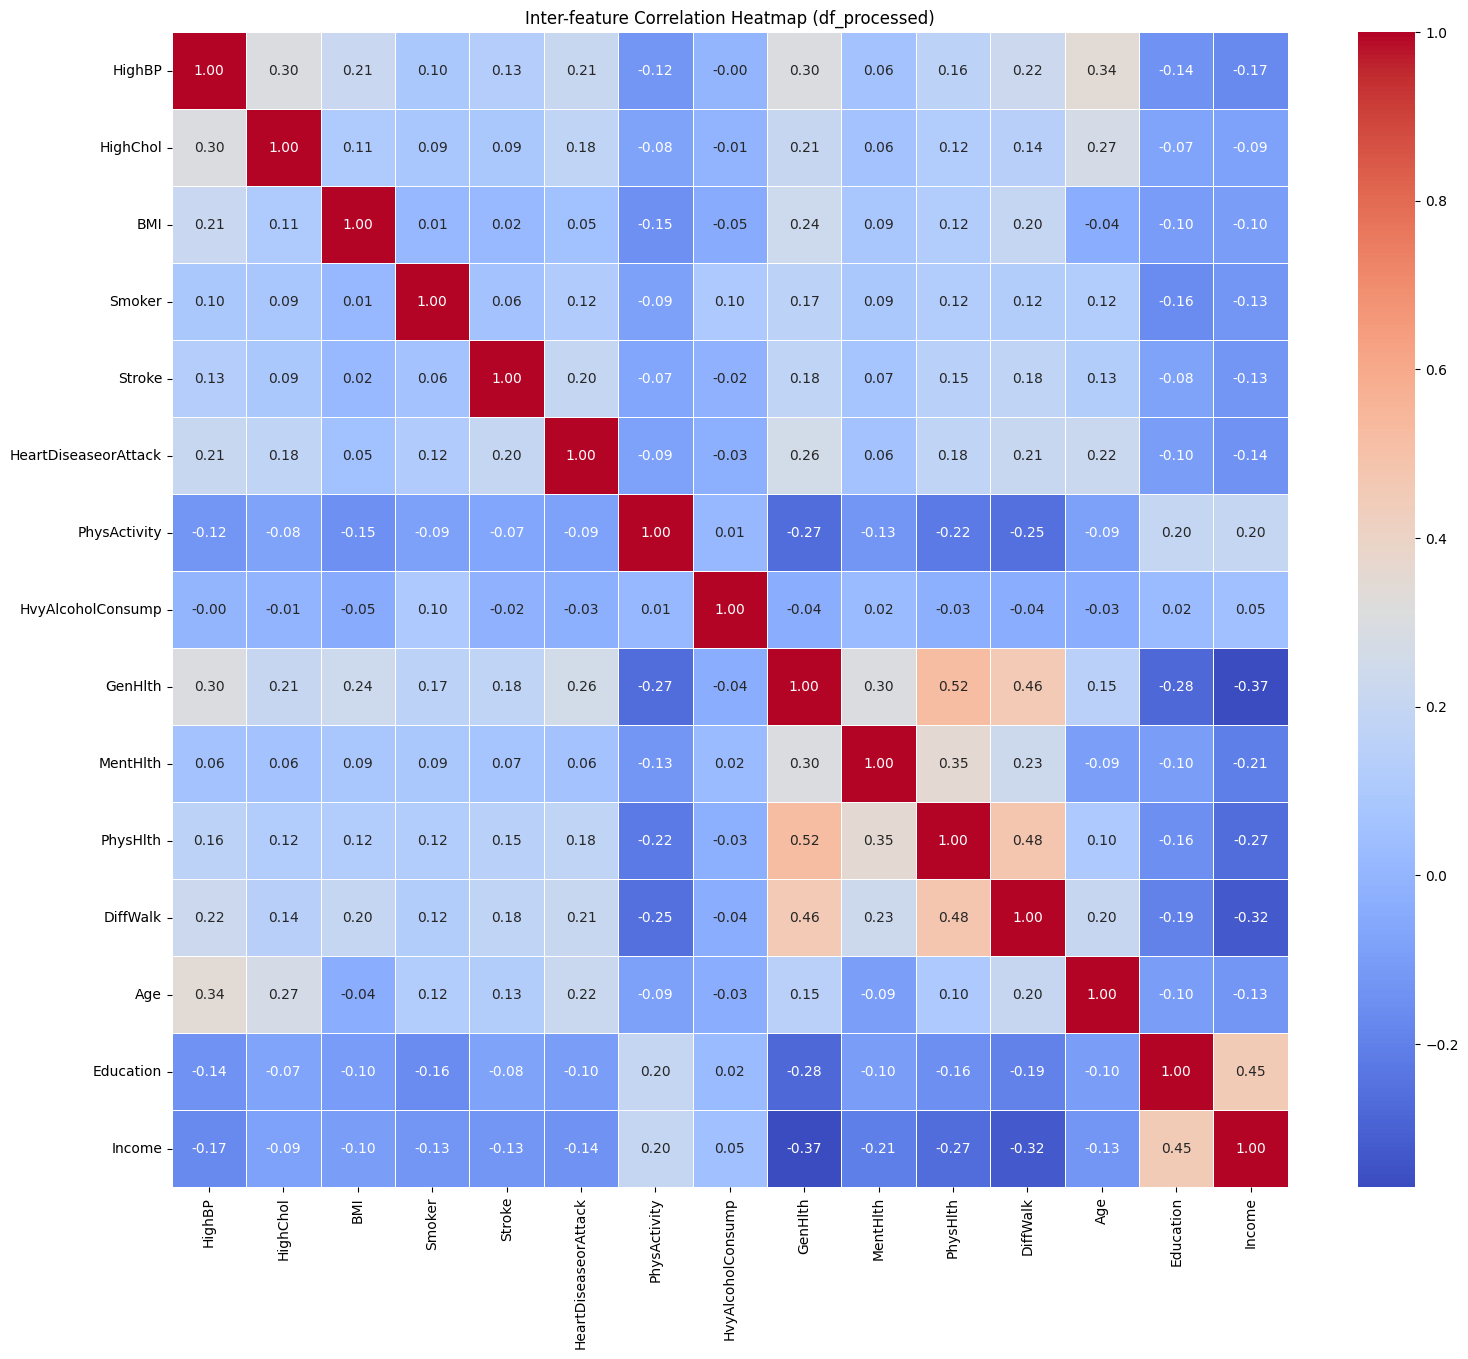

In [ ]:
import seaborn as sns
# Calculate the inter-feature correlation matrix for the processed DataFrame
correlation_matrix = df_processed.corr()

print("Inter-feature Correlation Matrix (first 5 rows/cols of df_processed):")
display(correlation_matrix.head())

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Inter-feature Correlation Heatmap (df_processed)')
plt.show()